In [5]:
# ── Dependencies ─────────────────────────────────────────────────────────────
# Standard data science stack.
# pymer4 wraps lme4 for mixed-effects models in Python (not used in final analysis).
# warnings suppressed to keep output clean during exploration.
# Experiment 3 — Headline Selection Analysis

# ── Install dependencies ─────────────────
# !pip install pandas numpy matplotlib seaborn statsmodels pymer4 stargazer

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import re
import warnings
warnings.filterwarnings("ignore")

In [6]:
# ── File paths ────────────────────────────────────────────────────────────────
# FILE_PATH:   raw Qualtrics export (CSV) from Experiment 3
# OUTPUT_PATH: cleaned, trial-level CSV written at the end of this notebook
FILE_PATH = "experiment3_main_run.csv"
OUTPUT_PATH = "experiment3_processed.csv"

In [7]:
# ════════════════════════════════════════════════════════════════════════════════
# SECTION 1 — Data Loading & Participant-Level Cleaning
# ════════════════════════════════════════════════════════════════════════════════
# Steps 0–6 convert the raw Qualtrics export into a clean participant-level
# dataframe before reshaping to trial level.
#
# Step 0: Load raw CSV and inspect shape.
# Step 1: Drop first 7 rows — Qualtrics header/preview rows, not real responses.
# Step 2: Resolve duplicate 'Q2' column names (Qualtrics reuses Q2 for both
#         the headline-cart selection and a demographic item). Rename to Q2 / Q2.1.
# Step 3: Strip and validate Prolific IDs; remove test/pilot rows.
# Step 4: Apply four attention checks:
#           Q11     — must answer '2'
#           Q15     — must answer '2'
#           Q2      — cart selection must include item 19 (embedded check headline)
#           Cred_19 — credibility rating for item 19 must equal 4
#         Only participants passing all four checks are retained.
# Step 5: (implicit) participant_df snapshot taken for downstream reshape.
# 0) Imports + load raw CSV

import pandas as pd
import numpy as np
import re
pd.set_option('display.max_columns', None)

df_raw = pd.read_csv(FILE_PATH, low_memory=False)
print("Raw shape:", df_raw.shape)

# 1) Drop first 5 preview / non-analytic rows

df = df_raw.iloc[7:].reset_index(drop=True).copy()
print("After dropping first 7 rows:", df.shape)


# 2) Fix duplicate Q2 column names

cols = list(df.columns)
q2_indices = [i for i, c in enumerate(cols) if c == "Q2"]
if len(q2_indices) >= 2:
    cols[q2_indices[0]] = "Q2"      # add-to-cart selections
    cols[q2_indices[1]] = "Q2.1"    # demographic item
    df.columns = cols


# 3) Basic participant cleaning

# Clean Prolific IDs
df["PROLIFIC_PID"] = df["PROLIFIC_PID"].astype(str).str.strip()
df["PROLIFIC_PID"] = df["PROLIFIC_PID"].replace(["", "nan", "None"], np.nan)

# Drop rows with missing Prolific IDs
df = df[df["PROLIFIC_PID"].notna()].copy()

# Remove obvious test rows
test_ids = ["megan", "asdfg"]
df = df[~df["PROLIFIC_PID"].isin(test_ids)].copy()

print("After ID cleaning:", df.shape)
print("Unique PROLIFIC_PID:", df["PROLIFIC_PID"].nunique())


# 4) Attention check cleaning

# Standardize fields
df["Q11"] = df["Q11"].astype(str).str.strip()
df["Q15"] = df["Q15"].astype(str).str.strip()
df["Q2"] = df["Q2"].astype(str).str.strip()
df["Cred_19"] = pd.to_numeric(df["Cred_19"], errors="coerce")

# Attention check 1: Q11 must equal 2
pass_q11 = df["Q11"] == "2"

# Attention check 2: Q15 must equal 2
pass_q15 = df["Q15"] == "2"

# Attention check 3: Q2 must include 19
def selected_19(q2_val):
    if pd.isna(q2_val):
        return False
    vals = [x.strip() for x in str(q2_val).split(",") if x.strip() != ""]
    return "19" in vals

pass_q2_19 = df["Q2"].apply(selected_19)

# Attention check 4: Cred_19 must equal 4
pass_cred19 = df["Cred_19"] == 4

# Keep only rows passing all checks
df = df[pass_q11 & pass_q15 & pass_q2_19 & pass_cred19].copy()

print("After attention checks:", df.shape)
print("Unique PROLIFIC_PID after attention checks:", df["PROLIFIC_PID"].nunique())

# 6) Final participant-level cleaned file

participant_df = df.copy()

print("\nFinal participant-level shape:", participant_df.shape)
print("Final analytic N:", participant_df["PROLIFIC_PID"].nunique())


# 7) Helper functions for Q2 / Q2_DO

def parse_selected_headline_numbers(q2_val):
    """
    Q2 contains the headline numbers selected into cart, e.g. '11,14,18,19'
    Returns a set of ints.
    """
    if pd.isna(q2_val):
        return set()

    vals = set()
    for x in str(q2_val).split(","):
        x = x.strip()
        if x == "":
            continue
        try:
            vals.add(int(x))
        except ValueError:
            pass
    return vals


def parse_display_order(q2_do_val):
    """
    Q2_DO contains the headline numbers in the order shown, e.g.
    '16|15|2|11|6|12|5|14|7|13|17|18|3|9|8|10|4|19|1'
    Returns a list of ints.
    """
    if pd.isna(q2_do_val):
        return []

    order = []
    for x in str(q2_do_val).split("|"):
        x = x.strip()
        if x == "":
            continue
        try:
            order.append(int(x))
        except ValueError:
            pass
    return order


# 8) Reshape to trial-level dataframe

records = []

demo_cols = [
    "ResponseId", "PROLIFIC_PID", "FL_19_DO",
    "Q1", "Q2.1", "Q3", "Q4_1", "Q4_2", "Q5", "Q6", "Q7",
    "Q8", "Q9_1", "Q9_2", "Q9_3", "Q11", "Q12", "Q13", "Q14",
    "Q15", "Q20"
]

for _, row in participant_df.iterrows():
    selected_headline_numbers = parse_selected_headline_numbers(row.get("Q2"))
    display_order = parse_display_order(row.get("Q2_DO"))

    # Build one row per displayed real headline (slots 1-18 only)
    for slot in range(1, 19):
        shown_headline_number = None
        if len(display_order) >= slot:
            shown_headline_number = display_order[slot - 1]

        rec = {
            "ResponseId": row.get("ResponseId"),
            "PROLIFIC_PID": row.get("PROLIFIC_PID"),
            "slot": slot,
            "shown_headline_number": shown_headline_number,
            "headline": row.get(f"S{slot}_Title"),
            "GOID": row.get(f"S{slot}_ID"),
            "cue_no": row.get(f"S{slot}_Cue"),
            "dimension": row.get(f"S{slot}_Dimension"),
            "instruction_raw": row.get("FL_19_DO"),
            "credibility_rating": row.get(f"Cred_{slot}"),
            "added_to_cart": int(shown_headline_number in selected_headline_numbers) if shown_headline_number is not None else np.nan,
        }

        for dc in demo_cols:
            if dc not in rec:
                rec[dc] = row.get(dc)

        records.append(rec)

result_df = pd.DataFrame(records)

print("\nTrial-level shape:", result_df.shape)
print("Expected rows:", len(participant_df) * 18)


# 9) Clean trial-level fields

result_df["credibility_rating"] = pd.to_numeric(result_df["credibility_rating"], errors="coerce")
result_df["added_to_cart"] = pd.to_numeric(result_df["added_to_cart"], errors="coerce")
result_df["shown_headline_number"] = pd.to_numeric(result_df["shown_headline_number"], errors="coerce")

# Clean dimension
result_df["dimension"] = result_df["dimension"].astype(str).str.strip().str.lower()
result_df["dimension"] = result_df["dimension"].replace(["", "nan", "none"], np.nan)

# Drop rows with missing dimension (invalid trial rows)
result_df = result_df[result_df["dimension"].notna()].copy()

print("\nAfter dropping missing-dimension rows:", result_df.shape)


# 10) Create analysis-ready variables

# Main DV
result_df["Selected"] = result_df["added_to_cart"].astype(int)

# Instruction coding
result_df["Instruction"] = result_df["instruction_raw"].map({
    "CredManipulation": 0,
    "EngManipulation": 1
})

# Morph dummies
result_df["MorphCredibility"] = (result_df["dimension"] == "credibility").astype(int)
result_df["MorphEngagement"] = (result_df["dimension"] == "engagement").astype(int)

# Cue type
result_df["cue_no"] = result_df["cue_no"].astype(str).str.strip()
result_df["cue_type"] = result_df["cue_no"].replace({
    "nan": np.nan,
    "None": np.nan,
    "": np.nan
})
result_df.loc[result_df["dimension"] == "neutral", "cue_type"] = "neutral"

# Headline IDs
result_df["GOID"] = result_df["GOID"].astype(str).str.strip()
result_df["headline_version_id"] = result_df["GOID"]
result_df["base_headline_id"] = result_df["GOID"].str.replace(r"_[EC][0-9]$", "", regex=True)

# Clean plot label
result_df["instruction_label"] = result_df["Instruction"].map({
    0: "credibility",
    1: "engagement"
})


# 11) Final analysis dataframe

analysis_df = result_df.copy()

print("\nFinal analysis_df shape:", analysis_df.shape)
print("Unique participants:", analysis_df["PROLIFIC_PID"].nunique())

print("\nRows per participant:")
print(analysis_df["PROLIFIC_PID"].value_counts().describe())

print("\nDimension counts:")
print(analysis_df["dimension"].value_counts(dropna=False))

print("\nSelected distribution:")
print(analysis_df["Selected"].value_counts(dropna=False))

print("\nInstruction distribution:")
print(analysis_df["Instruction"].value_counts(dropna=False))

print("\nCue type counts:")
print(analysis_df["cue_type"].value_counts(dropna=False).sort_index())

print("\nMorph coding check:")
print(
    analysis_df[["dimension", "MorphCredibility", "MorphEngagement"]]
    .drop_duplicates()
    .sort_values("dimension")
)

print("\nPreview:")
print(analysis_df[[
    "PROLIFIC_PID", "slot", "shown_headline_number", "headline",
    "GOID", "base_headline_id", "cue_type", "dimension",
    "credibility_rating", "Selected", "Instruction", "instruction_label"
]].head(20))




Raw shape: (792, 143)
After dropping first 7 rows: (785, 143)
After ID cleaning: (785, 143)
Unique PROLIFIC_PID: 785
After attention checks: (683, 143)
Unique PROLIFIC_PID after attention checks: 683

Final participant-level shape: (683, 143)
Final analytic N: 683

Trial-level shape: (12294, 30)
Expected rows: 12294

After dropping missing-dimension rows: (12276, 30)

Final analysis_df shape: (12276, 38)
Unique participants: 682

Rows per participant:
count    682.0
mean      18.0
std        0.0
min       18.0
25%       18.0
50%       18.0
75%       18.0
max       18.0
Name: count, dtype: float64

Dimension counts:
dimension
neutral        4092
engagement     4092
credibility    4092
Name: count, dtype: int64

Selected distribution:
Selected
0    8954
1    3322
Name: count, dtype: int64

Instruction distribution:
Instruction
0    6156
1    6120
Name: count, dtype: int64

Cue type counts:
cue_type
C1         1374
C2         1337
C3         1381
E1         1320
E2         1374
E3        

In [8]:
# ── Checkpoint save ───────────────────────────────────────────────────────────
# Save the analysis-ready trial-level dataframe for use in the R modeling script.
analysis_df.to_csv('analysis_df.csv', index=False)

In [9]:
# ════════════════════════════════════════════════════════════════════════════════
# SECTION 2 — Demographic Column Renaming
# ════════════════════════════════════════════════════════════════════════════════
# Qualtrics auto-names demographic items Q1–Q20. This cell maps them to
# descriptive labels (age, gender, political_party, etc.) for readability
# in downstream analyses and outputs.
# ╔══════════════════════════════════════════════════════════╗
# ║  STEP 6 — Rename demographic columns                    ║
# ╚══════════════════════════════════════════════════════════╝
result_df = analysis_df.copy()
result_df = result_df.rename(columns={
    "Q1":   "age",
    "Q2.1": "gender",
    "Q3":   "political_party",
    "Q4_1": "fiscal_beliefs",
    "Q4_2": "social_beliefs",
    "Q5":   "dem_or_rep",
    "Q6":   "lean_dem_or_rep",
    "Q7":   "race",
    "Q8":   "employment",
    "Q9_1": "parents_education_1",
    "Q9_2": "parents_education_2",
    "Q9_3": "parents_education_3",
    "Q11":  "attention_check_cashier",
    "Q12":  "household_income",
    "Q13":  "num_people_in_household",
    "Q14":  "family_social_class",
    "Q15":  "attention_check_two",
    "Q20":  "prolific_id_demo",
})

print("Final columns:")
print(result_df.columns.tolist())
print("\nAdded to cart distribution:")
print(result_df["added_to_cart"].value_counts())

Final columns:
['ResponseId', 'PROLIFIC_PID', 'slot', 'shown_headline_number', 'headline', 'GOID', 'cue_no', 'dimension', 'instruction_raw', 'credibility_rating', 'added_to_cart', 'FL_19_DO', 'age', 'gender', 'political_party', 'fiscal_beliefs', 'social_beliefs', 'dem_or_rep', 'lean_dem_or_rep', 'race', 'employment', 'parents_education_1', 'parents_education_2', 'parents_education_3', 'attention_check_cashier', 'household_income', 'num_people_in_household', 'family_social_class', 'attention_check_two', 'prolific_id_demo', 'Selected', 'Instruction', 'MorphCredibility', 'MorphEngagement', 'cue_type', 'headline_version_id', 'base_headline_id', 'instruction_label']

Added to cart distribution:
added_to_cart
0    8954
1    3322
Name: count, dtype: int64


In [10]:
# ════════════════════════════════════════════════════════════════════════════════
# SECTION 3 — Descriptive Summary: Selection by Instruction × Dimension
# ════════════════════════════════════════════════════════════════════════════════
# Computes the probability of selecting a headline (added_to_cart) for each
# combination of instruction condition and headline dimension (credibility /
# engagement / neutral).
#
# Two-stage aggregation to avoid Simpson's paradox:
#   1. Compute per-person selection proportion within each group.
#   2. Average those person-level proportions across participants.
# SE is the standard error of the person-level proportions.
# ╔══════════════════════════════════════════════════════════╗
# ║  STEP 7 — Summary table & Probability Plot #1           ║
# ╚══════════════════════════════════════════════════════════╝

# Person-level proportions first, then average across people
person_props = (
    result_df
    .dropna(subset=["instruction_raw", "dimension"])
    .groupby(["instruction_raw", "dimension", "PROLIFIC_PID"])["added_to_cart"]
    .mean()
    .reset_index(name="person_prop")
)

summary_table = (
    person_props
    .groupby(["instruction_raw", "dimension"])
    .agg(
        n_people    = ("person_prop", "count"),
        proportion  = ("person_prop", "mean"),
        se          = ("person_prop", lambda x: x.std() / np.sqrt(len(x)))
    )
    .reset_index()
)
print("\nSummary table (dimension):")
print(summary_table)


Summary table (dimension):
    instruction_raw    dimension  n_people  proportion        se
0  CredManipulation  credibility       342    0.267057  0.011340
1  CredManipulation   engagement       342    0.285575  0.010868
2  CredManipulation      neutral       342    0.284113  0.011946
3   EngManipulation  credibility       340    0.264706  0.010464
4   EngManipulation   engagement       340    0.252451  0.010743
5   EngManipulation      neutral       340    0.269608  0.011024


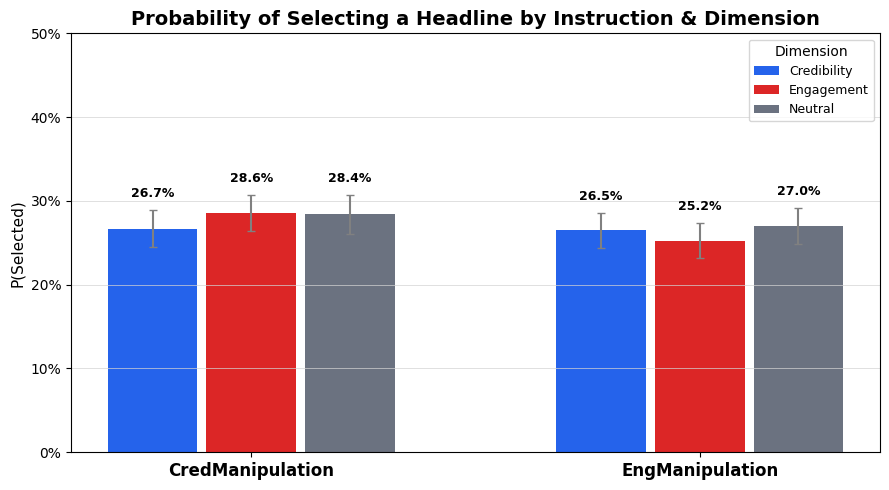

In [11]:
# ── Plot 1: Selection probability by instruction × dimension ─────────────────
# Grouped bar chart with 95% CI error bars.
# Each cluster of bars corresponds to one instruction condition;
# bars within a cluster represent headline dimension (credibility / engagement / neutral).
# Saved to: plot1_dimension_selection.png
# ── Plot #1 ───────────────────────────────────────────────────────────────────
dim_colors  = {"credibility": "#2563eb", "engagement": "#dc2626", "neutral": "#6b7280"}
instructions = summary_table["instruction_raw"].unique()
dimensions   = ["credibility", "engagement", "neutral"]

fig, ax = plt.subplots(figsize=(9, 5))
x       = np.arange(len(instructions))
n_dims  = len(dimensions)
width   = 0.6 / n_dims

for j, dim in enumerate(dimensions):
    sub   = summary_table[summary_table["dimension"] == dim].set_index("instruction_raw")
    props = [sub.loc[inst, "proportion"] if inst in sub.index else 0 for inst in instructions]
    ses   = [sub.loc[inst, "se"]         if inst in sub.index else 0 for inst in instructions]
    offset = (j - n_dims / 2 + 0.5) * (width + 0.02)
    bars = ax.bar(x + offset, props, width, label=dim.capitalize(), color=dim_colors[dim])
    ax.errorbar(x + offset, props, yerr=[1.96 * s for s in ses],
                fmt="none", color="grey", capsize=3)
    for xi, p, s in zip(x + offset, props, ses):   # unpack s here
        ax.text(xi, p + 1.96 * s + 0.012, f"{p*100:.1f}%", ha="center", va="bottom",
                fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(instructions, fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_ylim(0, 0.5)
ax.set_ylabel("P(Selected)", fontsize=11)
ax.set_title("Probability of Selecting a Headline by Instruction & Dimension",
             fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.legend(title="Dimension", fontsize=9)
ax.grid(axis="y", color="lightgrey", linewidth=0.5)
ax.set_facecolor("white")
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.savefig("plot1_dimension_selection.png", dpi=300)
plt.show()


In [12]:
# ════════════════════════════════════════════════════════════════════════════════
# SECTION 4 — Descriptive Summary: Selection by Instruction × Cue Type
# ════════════════════════════════════════════════════════════════════════════════
# Breaks down selection rates further by the specific linguistic cue applied
# to each headline (C1–C3 for credibility cues, E1–E3 for engagement cues, N neutral).
# SE computed from binomial variance formula: sqrt(p*(1-p)/n).
# ╔══════════════════════════════════════════════════════════╗
# ║  STEP 8 — Cue-type summary & Plot #2                    ║
# ╚══════════════════════════════════════════════════════════╝

summary_cue = (
    result_df
    .dropna(subset=["instruction_raw", "cue_no"])
    .query("instruction_raw != ''")
    .groupby(["instruction_raw", "cue_no"])
    .agg(
        n_headlines = ("added_to_cart", "count"),
        n_selected  = ("added_to_cart", "sum"),
        proportion  = ("added_to_cart", "mean")
    )
    .reset_index()
)
summary_cue["se"] = np.sqrt(
    summary_cue["proportion"] * (1 - summary_cue["proportion"]) / summary_cue["n_headlines"]
)
print("\nSummary table (cue type):")
print(summary_cue)


Summary table (cue type):
     instruction_raw cue_no  n_headlines  n_selected  proportion        se
0   CredManipulation     C1          659         183    0.277693  0.017446
1   CredManipulation     C2          677         178    0.262925  0.016919
2   CredManipulation     C3          716         187    0.261173  0.016416
3   CredManipulation     E1          669         175    0.261584  0.016992
4   CredManipulation     E2          709         213    0.300423  0.017217
5   CredManipulation     E3          674         198    0.293769  0.017545
6   CredManipulation      N         2052         583    0.284113  0.009956
7    EngManipulation     C1          715         201    0.281119  0.016812
8    EngManipulation     C2          660         164    0.248485  0.016821
9    EngManipulation     C3          665         175    0.263158  0.017076
10   EngManipulation     E1          651         168    0.258065  0.017150
11   EngManipulation     E2          665         155    0.233083  0.01639

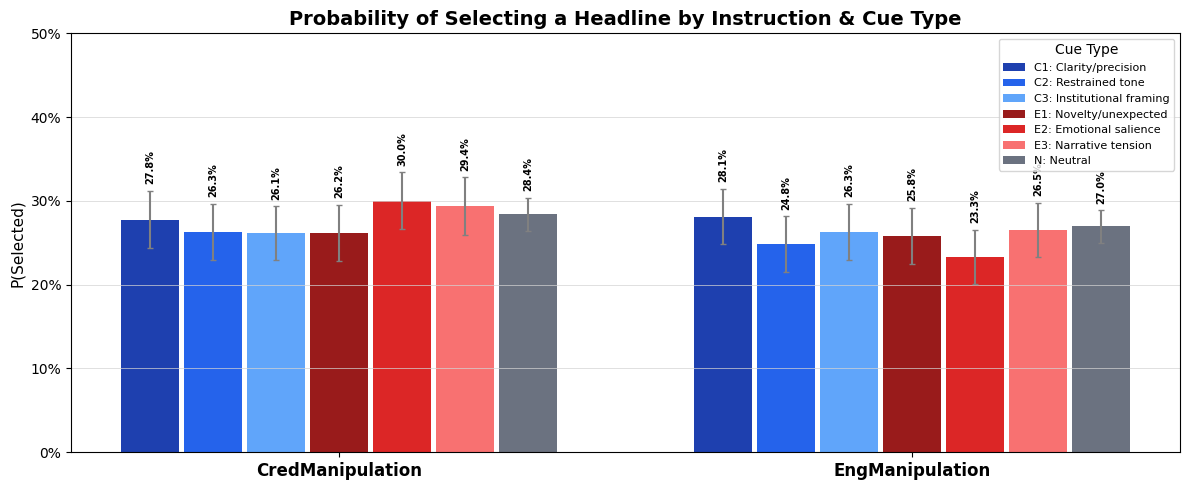

In [16]:
# ── Plot 2: Selection probability by instruction × cue type ──────────────────
# Same grouped-bar structure as Plot 1 but with 7 cue-type bars per instruction.
# Bars labelled with % values (rotated) to handle the dense layout.
# Color scheme: blue family for credibility cues, red family for engagement cues.
# Saved to: plot2_cue_selection.png
cue_colors = {
    "C1": "#1e40af", "C2": "#2563eb", "C3": "#60a5fa",
    "E1": "#991b1b", "E2": "#dc2626", "E3": "#f87171",
    "N":  "#6b7280"
}
cue_labels = {
    "C1": "C1: Clarity/precision", "C2": "C2: Restrained tone",
    "C3": "C3: Institutional framing", "E1": "E1: Novelty/unexpected",
    "E2": "E2: Emotional salience",  "E3": "E3: Narrative tension",
    "N":  "N: Neutral"
}

cue_order    = ["C1","C2","C3","E1","E2","E3","N"]
instructions = summary_cue["instruction_raw"].unique()
x            = np.arange(len(instructions))
width        = 0.7 / len(cue_order)

fig, ax = plt.subplots(figsize=(12, 5))
for j, cue in enumerate(cue_order):
    sub   = summary_cue[summary_cue["cue_no"] == cue].set_index("instruction_raw")
    props = [sub.loc[inst, "proportion"] if inst in sub.index else 0 for inst in instructions]
    ses   = [sub.loc[inst, "se"]         if inst in sub.index else 0 for inst in instructions]
    offset = (j - len(cue_order)/2 + 0.5) * (width + 0.01)
    ax.bar(x + offset, props, width, label=cue_labels[cue], color=cue_colors[cue])
    ax.errorbar(x + offset, props, yerr=[1.96*s for s in ses],
                fmt="none", color="grey", capsize=2)
    for xi, p, s in zip(x + offset, props, ses):
        ax.text(xi, p + 1.96 * s + 0.008, f"{p*100:.1f}%", ha="center", va="bottom",
                fontsize=7, fontweight="bold", rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(instructions, fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_ylim(0, 0.5)
ax.set_ylabel("P(Selected)", fontsize=11)
ax.set_title("Probability of Selecting a Headline by Instruction & Cue Type",
             fontsize=14, fontweight="bold")
ax.legend(title="Cue Type", fontsize=8, loc="upper right")
ax.grid(axis="y", color="lightgrey", linewidth=0.5)
ax.set_facecolor("white")
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.savefig("plot2_cue_selection.png", dpi=300)
plt.show()